Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.9637681159420289

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.94      0.97      0.96        69
  BrownNoise       0.91      0.97      0.94        69
       Clean       0.97      0.91      0.94        69
   PinkNoise       1.00      1.00      1.00        69
 VioletNoise       0.97      0.96      0.96        69
  WhiteNoise       1.00      0.97      0.99        69

    accuracy                           0.96       414
   macro avg       0.96      0.96      0.96       414
weighted avg       0.96      0.96      0.96       414


Confusion Matrix (Validation):
[[67  0  0  0  2  0]
 [ 0 67  2  0  0  0]
 [ 0  6 63  0  0  0]
 [ 0  0  0 69  0  0]
 [ 2  1  0  0 66  0]
 [ 2  0  0  0  0 67]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.9616666

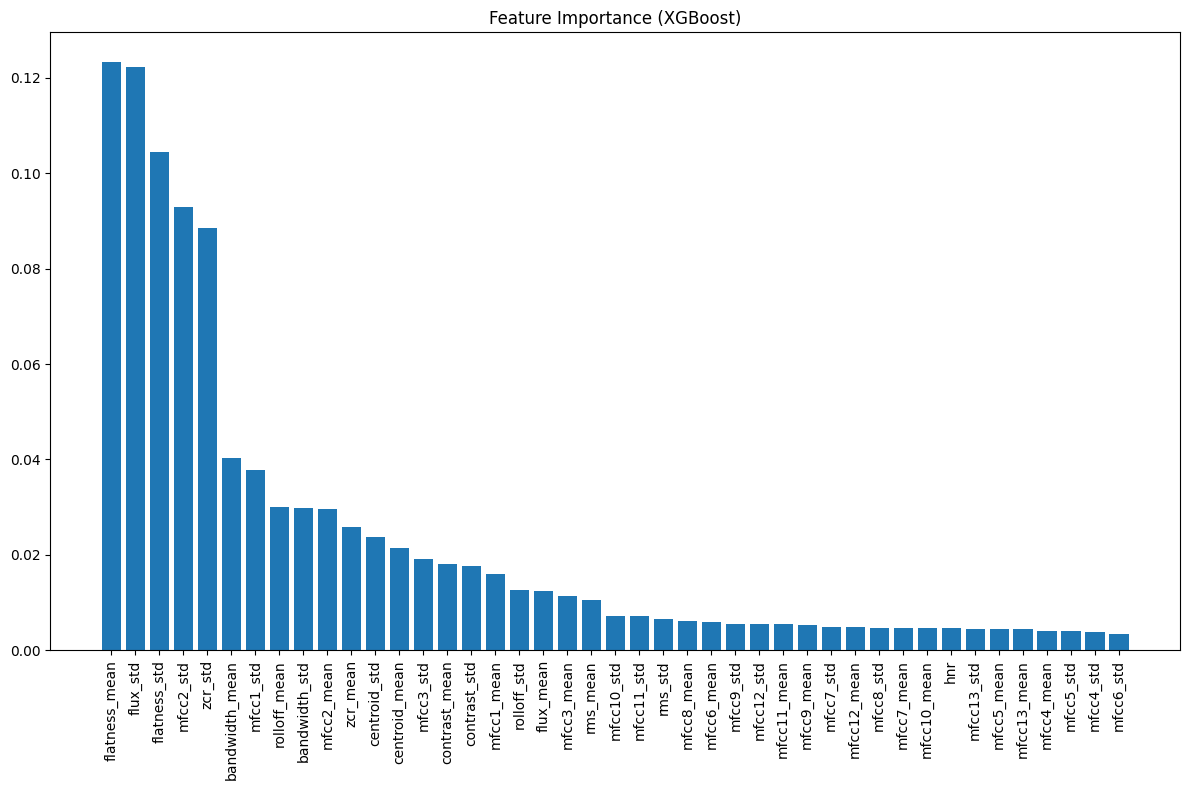


Top 15 vigtigste features:
flatness_mean: 0.1233
flux_std: 0.1223
flatness_std: 0.1043
mfcc2_std: 0.0930
zcr_std: 0.0885
bandwidth_mean: 0.0402
mfcc1_std: 0.0379
rolloff_mean: 0.0299
bandwidth_std: 0.0297
mfcc2_mean: 0.0296
zcr_mean: 0.0258
centroid_std: 0.0237
centroid_mean: 0.0214
mfcc3_std: 0.0191
contrast_mean: 0.0181


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features
irrelevant_cols = ["filnavn", "beta", "snr_db"]  # fjern beta og snr fra features
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])


# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. XGBOOST MODEL
# ----------------------------
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)


# fjern kun filnavn i testdata
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Split features og labels korrekt
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")
y_test_true = label_encoder.transform(df_test["target"])

# ---- HER PRINTER VI INFO OM TESTDATA ----
print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 7. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (XGBoost)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Print top 15 vigtigste features
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")



/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_53341/2683364247.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


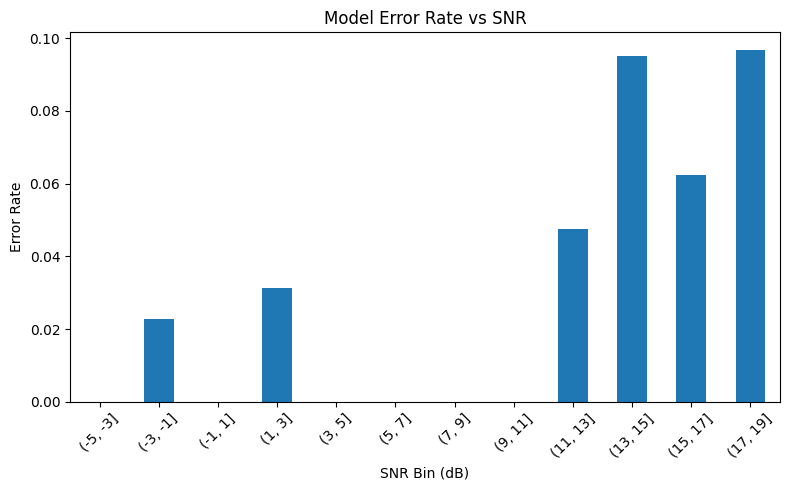

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_53341/2683364247.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


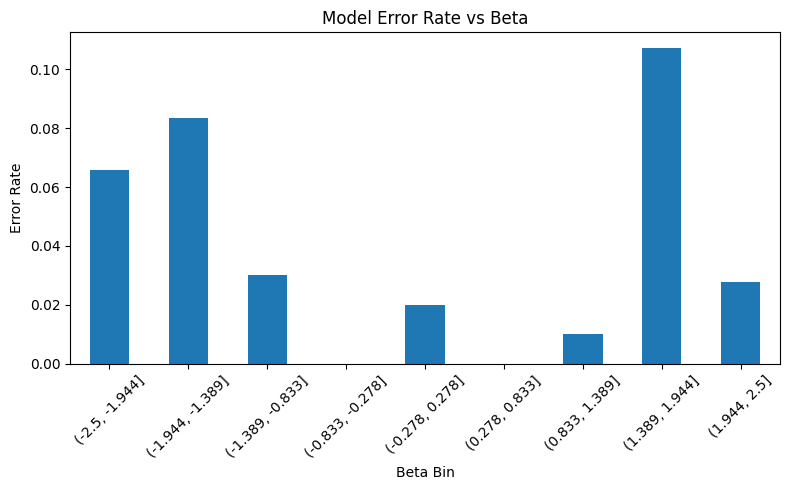


Test Accuracy: 0.9616666666666667

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.92      0.97      0.95       100
  BrownNoise       0.95      0.95      0.95       100
       Clean       0.93      0.95      0.94       100
   PinkNoise       1.00      0.99      0.99       100
 VioletNoise       0.99      0.93      0.96       100
  WhiteNoise       0.98      0.98      0.98       100

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600


Confusion Matrix (Test):
[[97  0  0  0  1  2]
 [ 0 95  5  0  0  0]
 [ 0  5 95  0  0  0]
 [ 0  0  1 99  0  0]
 [ 6  0  1  0 93  0]
 [ 2  0  0  0  0 98]]

Eksempler på fejl:
      true_label   pred_label  beta  snr_db
44     BlueNoise   WhiteNoise -0.99   18.24
48     BlueNoise   WhiteNoise -1.00   13.48
74     BlueNoise  VioletNoise -1.05   14.19
111   BrownNoise        Clean  1.92   19.1

In [5]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()
# fejlrate pr SNR
snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# fejlrate pr beta
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))


# ----------------------------
# ERROR ANALYSIS
# ----------------------------

df_analysis = df_test.copy()

df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))